In [1]:
import matplotlib.pyplot as plt
import torch
import torchvision
from tqdm import tqdm

from model import HORN

In [2]:
HORN?

Init signature: HORN(num_input, num_nodes, num_output, h, alpha, omega, gamma)
Docstring:     
Base class for all neural network modules.

Your models should also subclass this class.

Modules can also contain other Modules, allowing them to be nested in
a tree structure. You can assign the submodules as regular attributes::

    import torch.nn as nn
    import torch.nn.functional as F

    class Model(nn.Module):
        def __init__(self) -> None:
            super().__init__()
            self.conv1 = nn.Conv2d(1, 20, 5)
            self.conv2 = nn.Conv2d(20, 20, 5)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            return F.relu(self.conv2(x))

Submodules assigned in this way will be registered, and will also have their
parameters converted when you call :meth:`to`, etc.

.. note::
    As per the example above, an ``__init__()`` call to the parent class
    must be made before assignment on the child.

:ivar training: Boolean represents whether this m

In [3]:
# sMNIST as 1-dim time series
dim_input = 1

# 10 MNIST classes
dim_output = 10

In [4]:
model = HORN(dim_input, 32, dim_output, 1, 0.04, 0.224, 0.01)
model.load_state_dict(torch.load("out/epoch09.pt", weights_only=False))
model.eval()

HORN(
  (i2h): Linear(in_features=1, out_features=32, bias=True)
  (h2h): Linear(in_features=32, out_features=32, bias=True)
  (h2o): Linear(in_features=32, out_features=10, bias=True)
)

In [5]:
batch_size = 64
batch_size_train = batch_size

batch_size_test = 1000
# load dataset
size_validation = 1000  # size of validation dataset
train_set = torchvision.datasets.MNIST(
    root="data", train=True, transform=torchvision.transforms.ToTensor(), download=True
)
test_set = torchvision.datasets.MNIST(
    root="data", train=False, transform=torchvision.transforms.ToTensor(), download=True
)
train_set, valid_set = torch.utils.data.random_split(
    train_set, [len(train_set) - size_validation, size_validation]
)

# data loaders
train_loader = torch.utils.data.DataLoader(
    dataset=train_set, batch_size=batch_size_train, shuffle=True
)
valid_loader = torch.utils.data.DataLoader(
    dataset=valid_set, batch_size=batch_size_test, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_set, batch_size=batch_size_test, shuffle=False
)

In [6]:
inputs = valid_loader.dataset.dataset.data.reshape(-1, 1, 784).permute(2, 0, 1)[
    :, :1000
]
labels = valid_loader.dataset.dataset.targets[:1000]

In [7]:
pad = torch.zeros(500, 1000, 1)

In [8]:
inputs = torch.concat((pad, inputs, pad), axis=0)

In [9]:
inputs.shape

torch.Size([1784, 1000, 1])

In [10]:
output = model(inputs * 1.0, record="True")
prediction = output["output"]

In [11]:
prediction

tensor([[ -9.4520,   4.2622,   6.3550,  ...,  17.9818,  -4.6045,   3.2322],
        [-14.2508,   4.5401,   5.8506,  ...,  14.9975,  -3.0043,   4.3563],
        [-29.6571,  14.2995,   5.9110,  ...,  13.7159, -10.0122,   7.2321],
        ...,
        [ -3.3022,  -0.6482,   9.5901,  ...,  17.4321,  -1.6465,   1.8448],
        [-21.0214,   8.9513,   4.2819,  ...,  16.2219,  -5.2582,   5.2017],
        [-23.6804,   9.6395,   8.1999,  ...,  21.9539,  -5.9928,   7.0220]],
       grad_fn=<AddmmBackward0>)

In [12]:
pred_label = prediction.data.max(1, keepdim=True)[1]
pred_label.eq(labels.data.view_as(pred_label)).sum() / inputs.shape[1]

tensor(0.1120)

In [13]:
pred_label[pred_label.eq(labels.data.view_as(pred_label))]

tensor([7, 7, 7, 3, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7, 7, 7, 3,
        7, 7, 3, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 2, 7, 7, 7,
        2, 7, 7, 7, 7, 7, 7, 3, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 2, 7, 7, 7, 7, 7, 3, 7, 7, 7, 7, 3, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7])

In [14]:
labels[pred_label.eq(labels.data.view_as(pred_label)).squeeze()]

tensor([7, 7, 7, 3, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7, 7, 7, 3,
        7, 7, 3, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 2, 7, 7, 7,
        2, 7, 7, 7, 7, 7, 7, 3, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
        7, 2, 7, 7, 7, 7, 7, 3, 7, 7, 7, 7, 3, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7,
        7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7])

(array([ 3.,  0., 11.,  0.,  0.,  0.,  0.,  0.,  0., 98.]),
 array([2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. ]),
 <BarContainer object of 10 artists>)

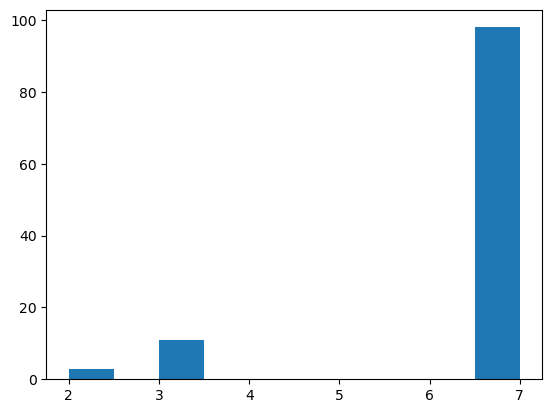

In [15]:
plt.hist(pred_label[pred_label.eq(labels.data.view_as(pred_label))])

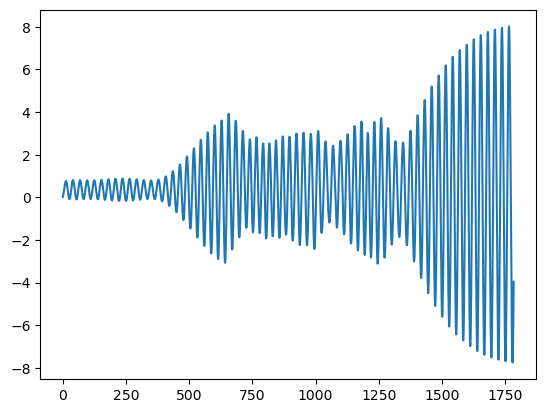

In [16]:
plt.plot(output["rec_x_t"][0][..., 5].detach().numpy())

In [17]:
# bce loss and optimizer for training
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)


def evaluate_model(data_loader, epoch=None, batch=None):

    model.eval()
    correct = 0
    test_loss = 0

    with torch.no_grad():
        # loop over batches in data loader
        for i, (images, labels) in enumerate(data_loader):
            # reshape batch
            images = images.reshape(batch_size_test, 1, 784)
            images = images.permute(2, 0, 1)

            # run model inference - record true returns dynamics
            output = model(images, record=True)
            prediction = output["output"]

            # compute loss + number of correct predictions
            test_loss += loss(prediction, labels).item()
            pred_label = prediction.data.max(1, keepdim=True)[1]
            correct += pred_label.eq(labels.data.view_as(pred_label)).sum()

    # compute loss and accuracy
    test_loss /= len(data_loader)
    accuracy = 100.0 * correct / len(data_loader.dataset)

    return accuracy.item()

In [18]:
evaluate_model(valid_loader, 1, batch_size_test)

91.69999694824219

In [19]:
from spectralMI import spectralMI

In [20]:
import numpy as np
import xarray as xr

In [21]:
data = xr.DataArray(
    output["rec_x_t"].detach().numpy().transpose(0, 2, 1),
    dims=("trials", "roi", "times"),
    coords={"trials": labels},
)

In [22]:
freqs = np.linspace(0.1, 60, 30)
out = spectralMI(
    data.isel(roi=[0, 1, 2, 3, 4]),
    labels,
    freqs,
    roi="roi",
    times="times",
    sfreq=1e3,
    n_cycles=freqs / 4,
    n_jobs=1,
)

Defining links (n_roi=5; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Computing pairwise spectral MI (n_pairs=10, n_freqs=30, decim=1)
100%|███████████████████████████████████████████| 10/10 [04:06<00:00, 24.63s/it]


In [23]:
freqs = np.linspace(0.1, 60, 30)
out_phase = spectralMI(
    data.isel(roi=[0, 1, 2, 3, 4]),
    labels,
    freqs,
    roi="roi",
    times="times",
    mode="phase",
    sfreq=1e3,
    n_cycles=freqs / 4,
    n_jobs=1,
)

Defining links (n_roi=5; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Computing pairwise spectral MI (n_pairs=10, n_freqs=30, decim=1)
100%|███████████████████████████████████████████| 10/10 [04:05<00:00, 24.56s/it]


In [24]:
out.shape

(10, 30, 1784)

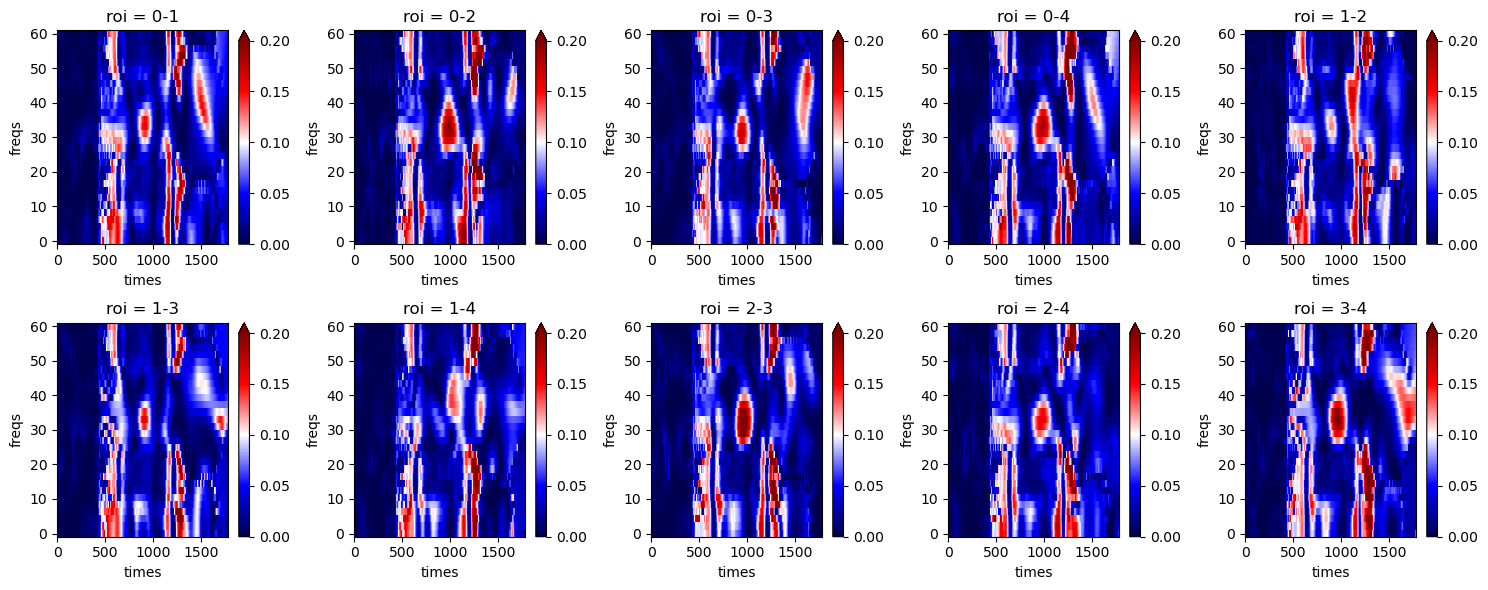

In [25]:
plt.figure(figsize=(15, 6))
for i in range(out.shape[0]):
    plt.subplot(2, 5, i + 1)
    out[i].plot(cmap="seismic", vmin=0, vmax=0.2)
plt.tight_layout()

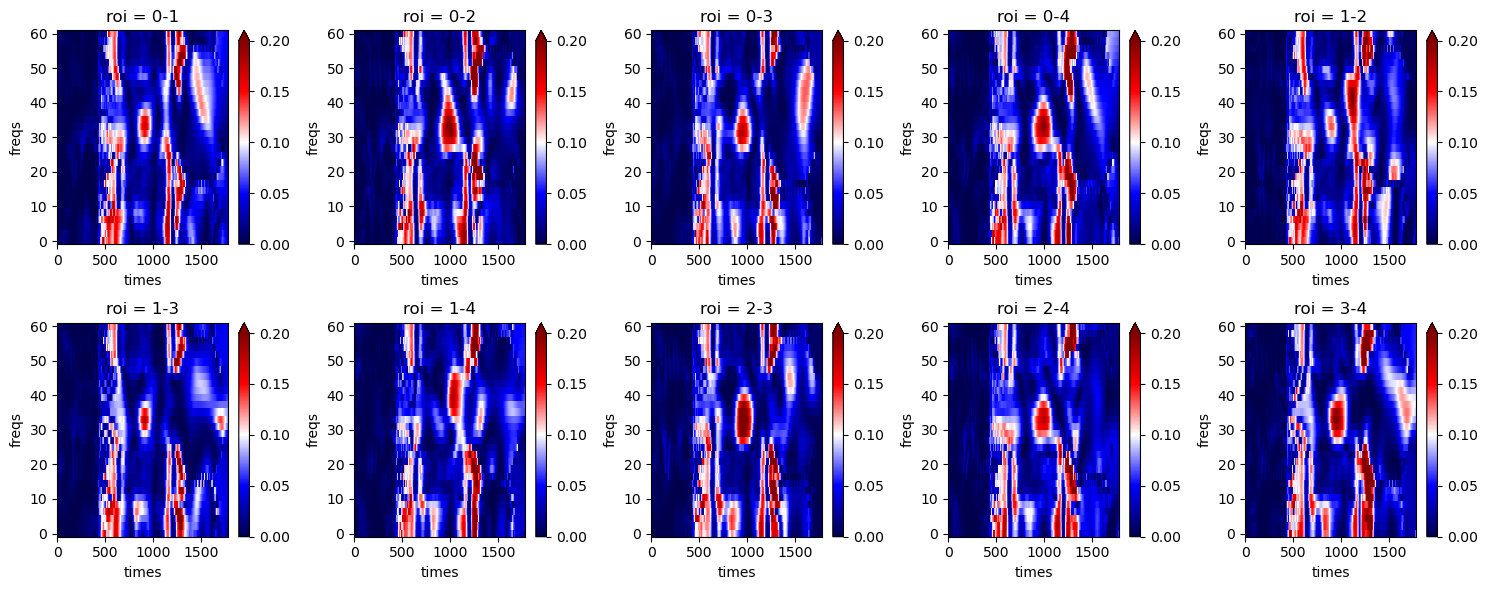

In [26]:
plt.figure(figsize=(15, 6))
for i in range(out.shape[0]):
    plt.subplot(2, 5, i + 1)
    out_phase[i].plot(cmap="seismic", vmin=0, vmax=0.2)
plt.tight_layout()

In [27]:
import scipy
from frites.core import (
    copnorm_nd,
    gccmi_nd_ccc,
    gcmi_1d_cc,
    gcmi_model_nd_cd,
    gcmi_nd_cc,
)

In [28]:
pairs = np.stack([roi.split("-") for roi in out.roi.values]).astype(int)

In [29]:
pairs

array([[0, 1],
       [0, 2],
       [0, 3],
       [0, 4],
       [1, 2],
       [1, 3],
       [1, 4],
       [2, 3],
       [2, 4],
       [3, 4]])

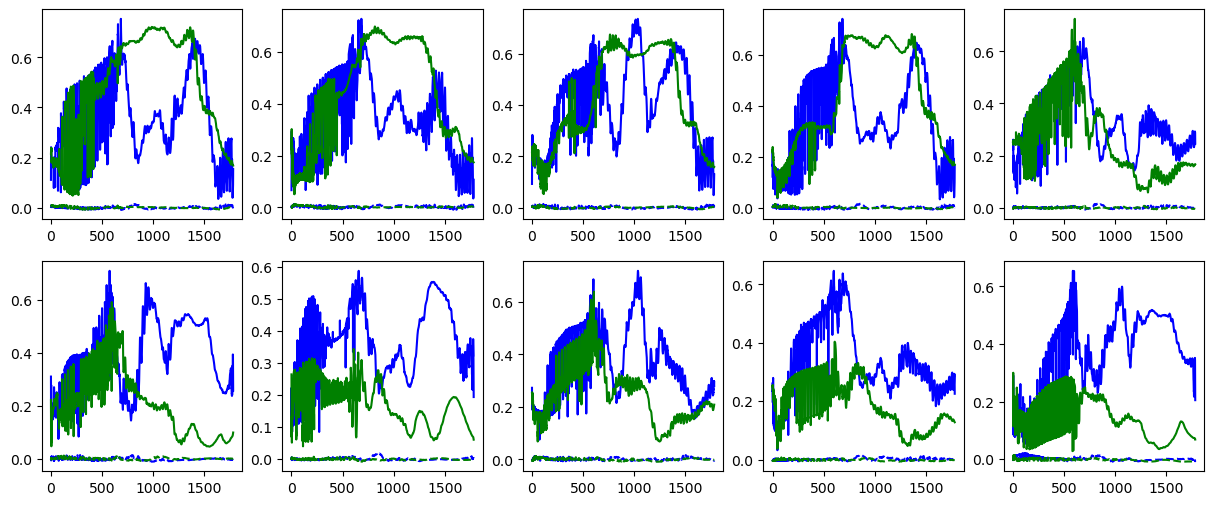

In [30]:
plt.figure(figsize=(15, 6))

labels = labels.detach().numpy()
labels_shuffle = labels[np.random.choice(range(len(labels)), len(labels))]

for pos, (i, j) in enumerate(pairs):
    plt.subplot(2, 5, pos + 1)
    h = scipy.signal.hilbert(data.isel(roi=[i, j]), axis=2)
    z = h[:, 0] * np.conj(h[:, 1])
    A = np.abs(z)
    dphi = np.unwrap(np.angle(z))

    I_S_R1 = gcmi_model_nd_cd(A, labels, traxis=0)
    I_S_R2 = gcmi_model_nd_cd(dphi, labels, traxis=0)

    I_S_R1_shuffle = gcmi_model_nd_cd(A, labels_shuffle, traxis=0)
    I_S_R2_shuffle = gcmi_model_nd_cd(dphi, labels_shuffle, traxis=0)

    plt.plot(I_S_R1, "b")
    plt.plot(I_S_R2, "g")

    plt.plot(I_S_R1_shuffle, "b--")
    plt.plot(I_S_R2_shuffle, "g--")

In [31]:
def circular_hist(
    ax, x, bins=16, density=True, offset=0, gaps=True, fill=False, alpha=0.3, color="b"
):
    """
    Produce a circular histogram of angles on ax.

    Parameters
    ----------
    ax : matplotlib.axes._subplots.PolarAxesSubplot
        axis instance created with subplot_kw=dict(projection='polar').

    x : array
        Angles to plot, expected in units of radians.

    bins : int, optional
        Defines the number of equal-width bins in the range. The default is 16.

    density : bool, optional
        If True plot frequency proportional to area. If False plot frequency
        proportional to radius. The default is True.

    offset : float, optional
        Sets the offset for the location of the 0 direction in units of
        radians. The default is 0.

    gaps : bool, optional
        Whether to allow gaps between bins. When gaps = False the bins are
        forced to partition the entire [-pi, pi] range. The default is True.

    Returns
    -------
    n : array or list of arrays
        The number of values in each bin.

    bins : array
        The edges of the bins.

    patches : `.BarContainer` or list of a single `.Polygon`
        Container of individual artists used to create the histogram
        or list of such containers if there are multiple input datasets.
    """
    # Wrap angles to [-pi, pi)
    x = (x + np.pi) % (2 * np.pi) - np.pi

    # Force bins to partition entire circle
    if not gaps:
        bins = np.linspace(-np.pi, np.pi, num=bins + 1)

    # Bin data and record counts
    n, bins = np.histogram(x, bins=bins)

    # Compute width of each bin
    widths = np.diff(bins)

    # By default plot frequency proportional to area
    if density:
        # Area to assign each bin
        area = n / x.size
        # Calculate corresponding bin radius
        radius = (area / np.pi) ** 0.5
    # Otherwise plot frequency proportional to radius
    else:
        radius = n

    # Plot data on ax
    patches = ax.bar(
        bins[:-1],
        radius,
        zorder=1,
        align="edge",
        width=widths,
        edgecolor="k",
        fill=fill,
        linewidth=1,
        alpha=alpha,
        color=color,
    )

    # Set the direction of the zero angle
    ax.set_theta_offset(offset)

    # Remove ylabels for area plots (they are mostly obstructive)
    if density:
        ax.set_yticks([])

    return n, bins, patches

In [36]:
i, j = pairs[3]
h = scipy.signal.hilbert(data.isel(roi=[i, j], times=slice(500, 500 + 28 * 28)), axis=2)
z = h[:, 0] * np.conj(h[:, 1])
A = np.abs(z)
dphi = np.unwrap(np.angle(z))

In [37]:
dphi = xr.DataArray(dphi, dims=("trials", "times"), coords={"trials": labels})

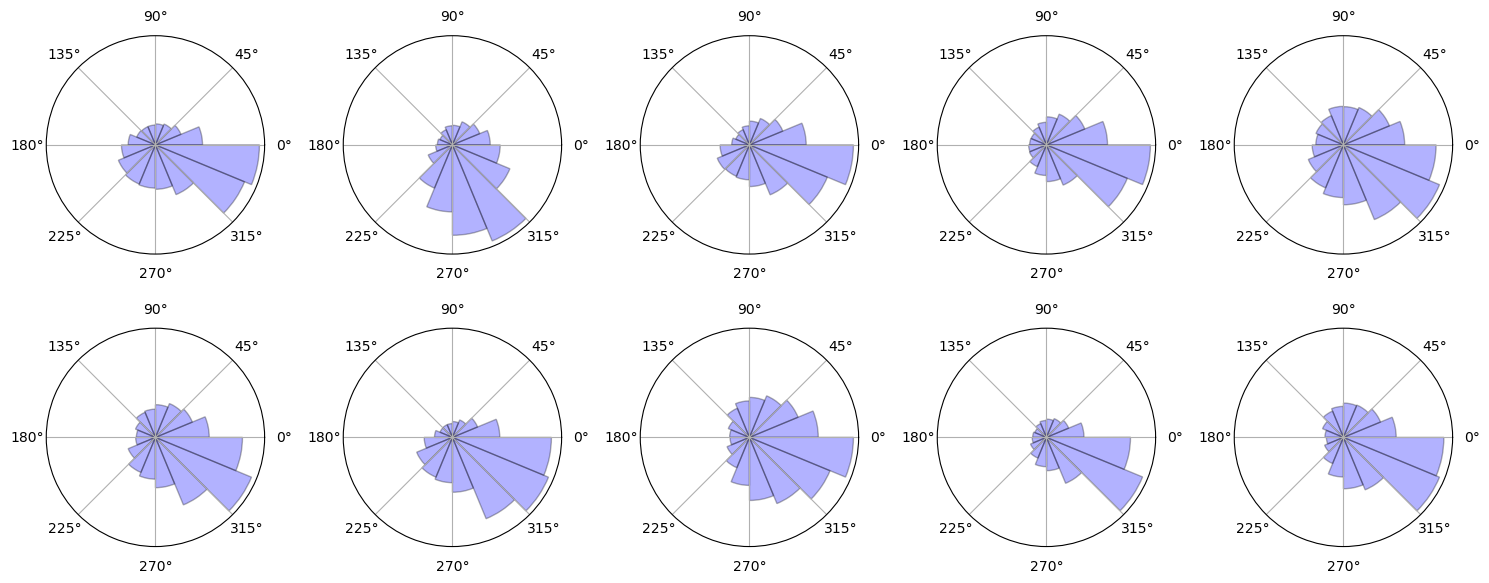

In [38]:
plt.figure(figsize=(15, 6))
cm2 = []
for i in range(10):
    ax = plt.subplot(2, 5, i + 1, projection="polar")
    circular_hist(ax, dphi.sel(trials=i).data.flatten(), fill=True)
    cm2 += [scipy.stats.circmean(dphi.sel(trials=i).data.flatten())]
plt.tight_layout()

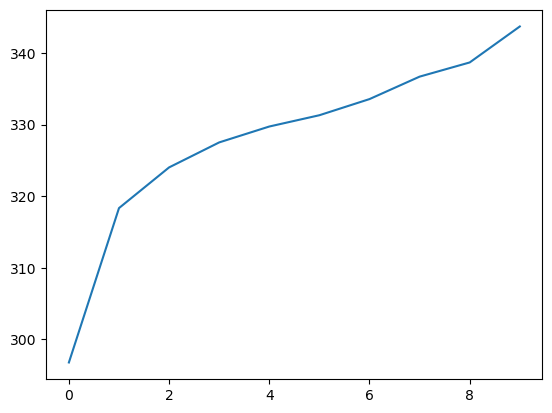

In [39]:
plt.plot(np.sort(cm2) * 180 / np.pi)